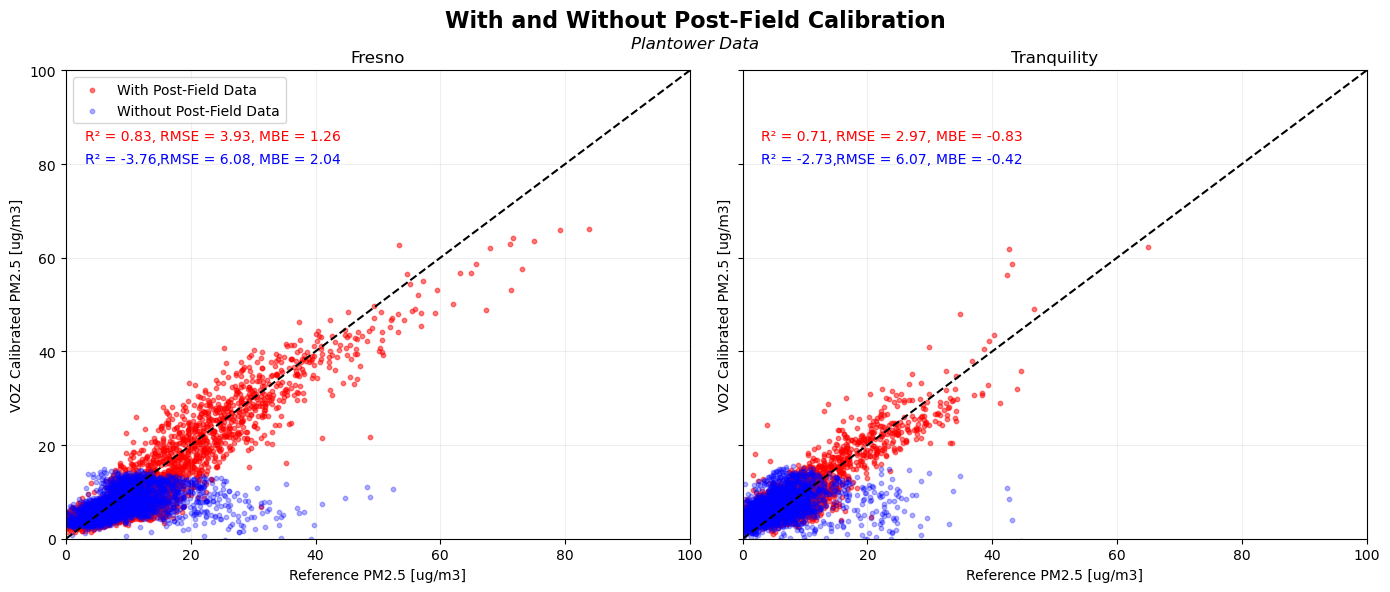

In [33]:
# Compare pre-calibration to both calibration datasets
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error

sensor = "Plantower"

filepath = rf"../reference_files/2023{sensor}DataCalibrated"

fgboth_path = os.path.join(filepath, "Fresno_Bothcalibrated.csv")
fgpre_path  = os.path.join(filepath, "Fresno_Precalibrated.csv")

trboth_path = os.path.join(filepath, "Tranquility_Bothcalibrated.csv")
trpre_path  = os.path.join(filepath, "Tranquility_Precalibrated.csv")

# Load your CSVs
fgboth = pd.read_csv(fgboth_path)
fgpre  = pd.read_csv(fgpre_path)

trboth = pd.read_csv(trboth_path)
trpre  = pd.read_csv(trpre_path)

# Column names (adjust if yours differ)
ref_col = "reference"
cal_col = "pm_calibrated_clarityremake"

def plotdetails(location,ax):
    axs[ax].plot([0, 100], [0, 100], c='black', linestyle='--')
    axs[ax].set_title(f"{location}")
    axs[ax].set_xlabel("Reference PM2.5 [ug/m3]")
    axs[ax].set_ylabel("VOZ Calibrated PM2.5 [ug/m3]")
    axs[ax].grid(True, alpha=0.2)
    axs[ax].set_ylim(0,100)
    axs[ax].set_xlim(0,100)

    if ax == 0:
        axs[ax].legend()

def plotmetrics(df1,df2,ax):
    r21 = r2_score(df1[cal_col], df1[ref_col])
    r22 = r2_score(df2[cal_col], df2[ref_col])
    rmse1 = root_mean_squared_error(df1[cal_col], df1[ref_col])
    rmse2 = root_mean_squared_error(df2[cal_col], df2[ref_col])
    mbe1 = (df1[ref_col] - df1[cal_col]).mean()
    mbe2 = (df2[ref_col] - df2[cal_col]).mean()
    axs[ax].text(0.03, 0.875, f'R\u00b2 = {r21:.2f},', transform=axs[ax].transAxes, fontsize=10, color="red", verticalalignment='top')
    axs[ax].text(0.03, 0.825, f'R\u00b2 = {r22:.2f},', transform=axs[ax].transAxes, fontsize=10, color="blue", verticalalignment='top')
    axs[ax].text(0.15, 0.875, f'RMSE = {rmse1:.2f},', transform=axs[ax].transAxes, fontsize=10, color="red", verticalalignment='top')
    axs[ax].text(0.15, 0.825, f'RMSE = {rmse2:.2f},', transform=axs[ax].transAxes, fontsize=10, color="blue", verticalalignment='top')
    axs[ax].text(0.31, 0.875, f'MBE = {mbe1:.2f}', transform=axs[ax].transAxes, fontsize=10, color="red", verticalalignment='top')
    axs[ax].text(0.31, 0.825, f'MBE = {mbe2:.2f}', transform=axs[ax].transAxes, fontsize=10, color="blue", verticalalignment='top')


fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

fig.suptitle(f"With and Without Post-Field Calibration", fontsize="16",fontweight="bold")
fig.text(0.5, 0.915, f"{sensor} Data", ha='center', fontsize=12, fontstyle = "italic")

# --- LEFT SUBPLOT: Fresno ---
axs[0].scatter(fgboth[ref_col], fgboth[cal_col], s=10, c="red", alpha=0.5, label="With Post-Field Data")
axs[0].scatter(fgpre[ref_col],  fgpre[cal_col],  s=10, c="blue", alpha=0.3, label="Without Post-Field Data")
plotmetrics(fgboth,fgpre,0)
plotdetails("Fresno",0)

# --- RIGHT SUBPLOT: Tranquility ---
axs[1].scatter(trboth[ref_col], trboth[cal_col], s=10, c="red",  alpha=0.5)
axs[1].scatter(trpre[ref_col],  trpre[cal_col],  s=10, c="blue", alpha=0.3)
plotmetrics(trboth,trpre,1)
plotdetails("Tranquility",1)

plt.tight_layout()
plt.savefig(rf"../../2023pmpaperfigures/CalibrationComparison/{sensor}PreFieldvsBoth.jpg", format='jpg', dpi=300)
plt.show()

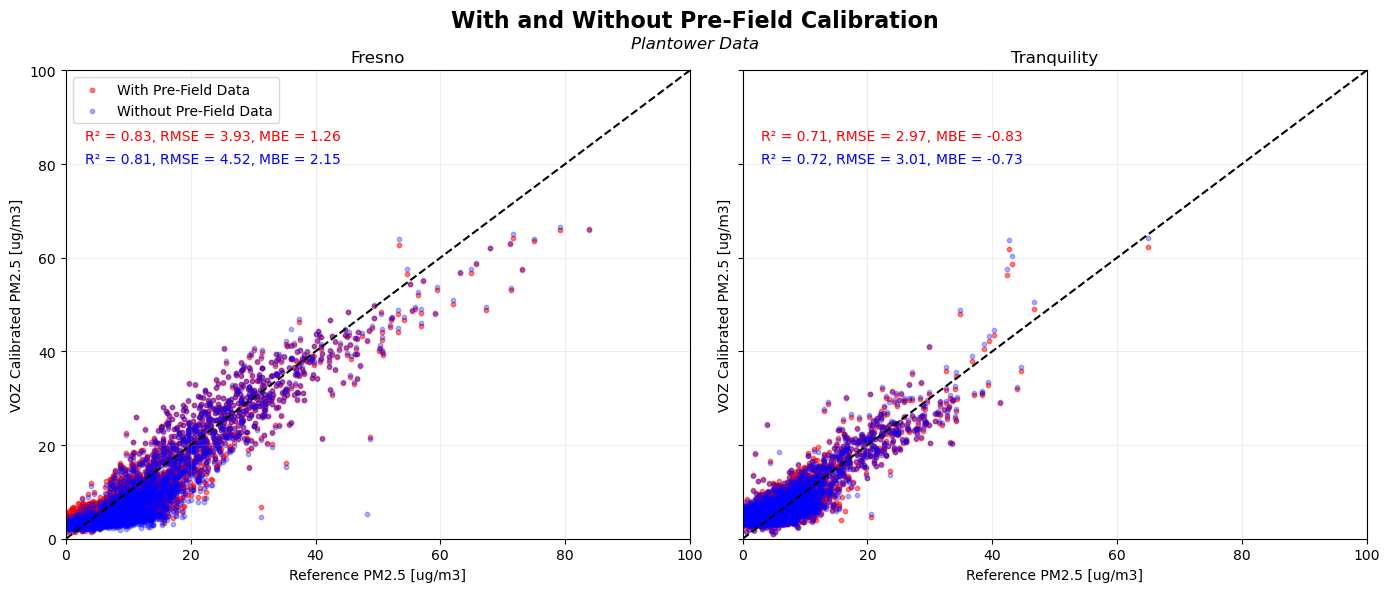

In [34]:
# Compare post-calibration to both calibration datasets
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error

sensor = "Plantower"

filepath = rf"../reference_files/2023{sensor}DataCalibrated"

fgboth_path = os.path.join(filepath, "Fresno_Bothcalibrated.csv")
fgpost_path  = os.path.join(filepath, "Fresno_Postcalibrated.csv")

trboth_path = os.path.join(filepath, "Tranquility_Bothcalibrated.csv")
trpost_path  = os.path.join(filepath, "Tranquility_Postcalibrated.csv")

# Load your CSVs
fgboth = pd.read_csv(fgboth_path)
fgpost  = pd.read_csv(fgpost_path)

trboth = pd.read_csv(trboth_path)
trpost  = pd.read_csv(trpost_path)

# Column names (adjust if yours differ)
ref_col = "reference"
cal_col = "pm_calibrated_clarityremake"

def plotdetails(location,ax):
    axs[ax].plot([0, 100], [0, 100], c='black', linestyle='--')
    axs[ax].set_title(f"{location}")
    axs[ax].set_xlabel("Reference PM2.5 [ug/m3]")
    axs[ax].set_ylabel("VOZ Calibrated PM2.5 [ug/m3]")
    axs[ax].grid(True, alpha=0.2)
    axs[ax].set_ylim(0,100)
    axs[ax].set_xlim(0,100)

    if ax == 0:
        axs[ax].legend()

def plotmetrics(df1,df2,ax):
    r21 = r2_score(df1[cal_col], df1[ref_col])
    r22 = r2_score(df2[cal_col], df2[ref_col])
    rmse1 = root_mean_squared_error(df1[cal_col], df1[ref_col])
    rmse2 = root_mean_squared_error(df2[cal_col], df2[ref_col])
    mbe1 = (df1[ref_col] - df1[cal_col]).mean()
    mbe2 = (df2[ref_col] - df2[cal_col]).mean()
    axs[ax].text(0.03, 0.875, f'R\u00b2 = {r21:.2f},', transform=axs[ax].transAxes, fontsize=10, color="red", verticalalignment='top')
    axs[ax].text(0.03, 0.825, f'R\u00b2 = {r22:.2f},', transform=axs[ax].transAxes, fontsize=10, color="blue", verticalalignment='top')
    axs[ax].text(0.15, 0.875, f'RMSE = {rmse1:.2f},', transform=axs[ax].transAxes, fontsize=10, color="red", verticalalignment='top')
    axs[ax].text(0.15, 0.825, f'RMSE = {rmse2:.2f},', transform=axs[ax].transAxes, fontsize=10, color="blue", verticalalignment='top')
    axs[ax].text(0.31, 0.875, f'MBE = {mbe1:.2f}', transform=axs[ax].transAxes, fontsize=10, color="red", verticalalignment='top')
    axs[ax].text(0.31, 0.825, f'MBE = {mbe2:.2f}', transform=axs[ax].transAxes, fontsize=10, color="blue", verticalalignment='top')


fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

fig.suptitle(f"With and Without Pre-Field Calibration", fontsize="16",fontweight="bold")
fig.text(0.5, 0.915, f"{sensor} Data", ha='center', fontsize=12, fontstyle = "italic")

# --- LEFT SUBPLOT: Fresno ---
axs[0].scatter(fgboth[ref_col], fgboth[cal_col], s=10, c="red", alpha=0.5, label="With Pre-Field Data")
axs[0].scatter(fgpost[ref_col],  fgpost[cal_col],  s=10, c="blue", alpha=0.3, label="Without Pre-Field Data")
plotmetrics(fgboth,fgpost,0)
plotdetails("Fresno",0)

# --- RIGHT SUBPLOT: Tranquility ---
axs[1].scatter(trboth[ref_col], trboth[cal_col], s=10, c="red",  alpha=0.5)
axs[1].scatter(trpost[ref_col],  trpost[cal_col],  s=10, c="blue", alpha=0.3)
plotmetrics(trboth,trpost,1)
plotdetails("Tranquility",1)

plt.tight_layout()
plt.savefig(rf"../../2023pmpaperfigures/CalibrationComparison/{sensor}PostFieldvsBoth.jpg", format='jpg', dpi=300)
plt.show()